In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import transportation_models.utils.fetch_wandb_results as fwr

In [7]:
filters={
    "tags":"presentation",
}
records_df = fwr.fetch_runs(filters=filters)
summary_df = fwr.best_flow_rmse_summary(records_df)
summary_df = summary_df.sort_values(by="created_at").reset_index(drop=True)

summary_df["experiment"] = "physics loss ablation"
summary_df["config/missing_rate"] = 0.0
summary_df.loc[summary_df["run_name"].isin(["zany-wood-112", "wandering-universe-126"]), "experiment"] = "MinMax"
summary_df = summary_df.loc[~summary_df['run_name'].isin(["smart-firefly-102", "fanciful-blaze-102"]), :]
summary_df.loc[0:11, "config/missing_rate"] = 0.1
summary_df.loc[12:, "config/missing_rate"] = 0.5
summary_df.loc[summary_df["run_name"].isin(["northern-music-124", "mild-tree-125"]), "config/missing_rate"] = 0.1
summary_df.loc[:, ["run_name", "created_at", "summary/val_flow_rmse", "config/PhysWeight", "experiment", "config/missing_rate"]]

,run_name,created_at,summary/val_flow_rmse,config/PhysWeight,experiment,config/missing_rate
0,feasible-dust-101,2026-04-17T04:59:39Z,90.422272,0.0,physics loss ablation,0.1
3,wild-smoke-104,2026-04-17T05:30:57Z,113.128838,0.2,physics loss ablation,0.1
4,azure-fog-106,2026-04-17T05:31:02Z,104.561943,0.4,physics loss ablation,0.1
5,vivid-glitter-105,2026-04-17T05:31:02Z,108.098961,0.5,physics loss ablation,0.1
6,easy-shape-107,2026-04-17T05:31:03Z,96.014282,0.3,physics loss ablation,0.1
7,denim-glade-108,2026-04-17T05:31:17Z,893.608704,0.9,physics loss ablation,0.1
8,gentle-hill-109,2026-04-17T05:31:58Z,94.958496,0.1,physics loss ablation,0.1
9,upbeat-salad-111,2026-04-17T05:32:03Z,124.406029,0.8,physics loss ablation,0.1
10,feasible-violet-110,2026-04-17T05:32:03Z,989.696594,1.0,physics loss ablation,0.1
11,zany-wood-112,2026-04-17T05:50:18Z,92.521080,0.0,MinMax,0.1


In [14]:
summary_df.loc[(summary_df['experiment'] == "physics loss ablation") & (summary_df['config/missing_rate'] == 0.5), ["run_name", "experiment", "config/missing_rate", "config/PhysWeight", "summary/val_flow_rmse",]]

,run_name,experiment,config/missing_rate,config/PhysWeight,summary/val_flow_rmse
12,charmed-night-113,physics loss ablation,0.5,0.2,114.087669
13,grateful-blaze-114,physics loss ablation,0.5,0.1,100.499542
14,vague-fire-115,physics loss ablation,0.5,0.4,111.323769
15,cosmic-plant-116,physics loss ablation,0.5,0.8,124.820915
16,valiant-salad-117,physics loss ablation,0.5,0.9,987.890076
17,light-sky-118,physics loss ablation,0.5,1.0,987.890076
18,driven-blaze-119,physics loss ablation,0.5,0.3,109.499420
20,true-totem-121,physics loss ablation,0.5,0.7,127.406906
21,misunderstood-darkness-122,physics loss ablation,0.5,0.6,132.889221
22,solar-vortex-123,physics loss ablation,0.5,0.5,116.671921


# Physics Loss Ablation Study Results
Let's compare the accuracy of models trained with different contributions of physics loss

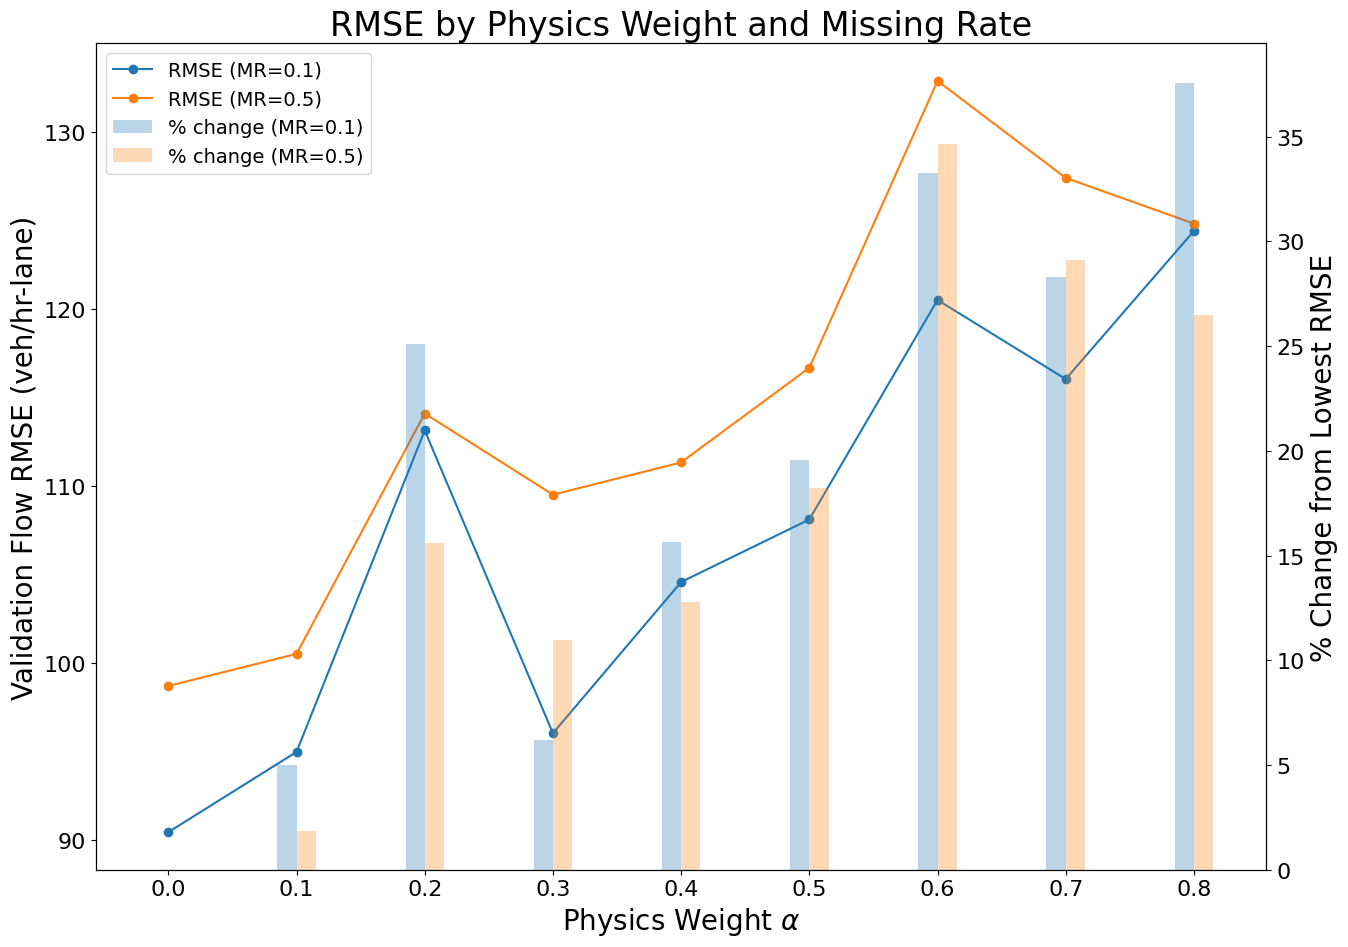

In [12]:
df = summary_df.loc[summary_df['experiment'] == 'physics loss ablation', ["config/PhysWeight", "config/missing_rate", "summary/val_flow_rmse"]]
df_pivot = df.pivot_table(index="config/PhysWeight", columns="config/missing_rate", values="summary/val_flow_rmse")
df_pivot = df_pivot.loc[0:0.8, :]

plt.rcParams.update(
    {
        "font.size": 24,
        "axes.titlesize": 24,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
    }
)


fig, ax1 = plt.subplots(figsize=(14, 10))

# Line chart: RMSE values
for col in df_pivot.columns:
    ax1.plot(df_pivot.index, df_pivot[col], marker='o', label=f"RMSE (MR={col})")
ax1.set_xlabel(r"Physics Weight $\alpha$")
ax1.set_ylabel("Validation Flow RMSE (veh/hr-lane)")
ax1.set_xticks(df_pivot.index)

# Bar chart: percent change relative to lowest RMSE per missing rate
ax2 = ax1.twinx()
min_rmse = df_pivot.min()
pct_change = ((df_pivot - min_rmse) / min_rmse) * 100
bar_width = 0.015
offsets = [-bar_width / 2, bar_width / 2]
for i, col in enumerate(pct_change.columns):
    ax2.bar(pct_change.index + offsets[i], pct_change[col], width=bar_width, alpha=0.3, label=f"% change (MR={col})")
ax2.set_ylabel("% Change from Lowest RMSE")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("RMSE by Physics Weight and Missing Rate")
fig.tight_layout()
plt.show()